# Multi-Label Audio Event Detection

Converted from `alm_audio_encoder_training.ipynb`

**Key changes from original (single-label):**
- ❌ Removed: `softmax`, `CrossEntropyLoss`, single-label target
- ✅ Added: `BCEWithLogitsLoss`, multi-hot targets, audio mixing augmentation, threshold inference, F1/Precision/Recall evaluation

## 1️⃣ Imports & CUDA Setup

In [3]:
import os
import sys
import time
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn

import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import torchaudio.transforms as T


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, multilabel_confusion_matrix,
    f1_score, precision_score, recall_score
)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── CUDA Check ────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 55)
print(f"  PyTorch  : {torch.__version__}")
print(f"  CUDA     : {torch.version.cuda}")
print(f"  Device   : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"  GPU      : {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"  VRAM     : {vram:.1f} GB")
print("=" * 55)

  PyTorch  : 2.5.1+cu121
  CUDA     : 12.1
  Device   : cuda
  GPU      : NVIDIA GeForce RTX 2050
  VRAM     : 4.0 GB


## 2️⃣ Configuration

In [16]:
class CFG:
    # ── Paths ─────────────────────────────────────────────────────────────────
    DATA_DIR      = Path(r"C:\Users\shara\Desktop\ALM\data\processed")
    AUDIO_DIR     = DATA_DIR / "audio"
    METADATA_PATH = DATA_DIR / "metadata.csv"
    MODEL_DIR     = Path(r"C:\Users\shara\Desktop\ALM\models")
    MODEL_DIR.mkdir(parents=True, exist_ok=True)

    # ── Audio ─────────────────────────────────────────────────────────────────
    SAMPLE_RATE   = 24_000
    DURATION      = 5
    NUM_SAMPLES   = 120_000
    N_MELS        = 128
    N_FFT         = 1024
    HOP_LENGTH    = 512
    F_MIN         = 0
    F_MAX         = 8_000

    # ── Model ─────────────────────────────────────────────────────────────────
    EMBED_DIM     = 256
    NUM_HEADS     = 8
    NUM_LAYERS    = 4
    FF_DIM        = 1024
    DROPOUT       = 0.1

    # ── Training ──────────────────────────────────────────────────────────────
    EPOCHS        = 50
    BATCH_SIZE    = 16
    LR            = 3e-4
    WEIGHT_DECAY  = 1e-4
    VAL_FOLD      = 9
    TEST_FOLD     = 10
    GRAD_CLIP     = 1.0
    AMP           = True
    PATIENCE      = 15

    # ── Thresholds ────────────────────────────────────────────────────────────
    # Per-class overrides for chronically over-firing classes
    CLASS_THRESHOLDS = {
        "gun_shot"  : 0.55,
        "siren"     : 0.50,
        "fireworks" : 0.45,
        "train"     : 0.50,   # was firing at 0.97 on fireworks samples
    }
    DEFAULT_THRESHOLD = 0.35   # all classes not listed above
    TOP_K_FALLBACK    = 1      # if nothing clears threshold, take top-1 only

    # ── Augmentation ─────────────────────────────────────────────────────────
    # RARE_AUG_MULT is defined but not consumed by _augment_wave —
    # kept here for documentation only until the next retrain
    RARE_CLASSES     = {"scream"}        # removed gun_shot + siren (overfit)
    EXPLOSION_LIKE   = {"fireworks", "gun_shot", "thunder"}  # skip mixing
    MIX_PROB         = 0.20              # was 0.40 — main cause of gun_shot bleed
    MIX_ALPHA        = 0.4

    DEVICE           = DEVICE


print("✅ Config loaded (multi-label mode)")
print(f"   Default threshold : {CFG.DEFAULT_THRESHOLD}")
print(f"   Per-class overrides: {CFG.CLASS_THRESHOLDS}")
print(f"   Rare aug classes  : {CFG.RARE_CLASSES}")
print(f"   Mix prob          : {CFG.MIX_PROB}")

✅ Config loaded (multi-label mode)
   Default threshold : 0.35
   Per-class overrides: {'gun_shot': 0.55, 'siren': 0.5, 'fireworks': 0.45, 'train': 0.5}
   Rare aug classes  : {'scream'}
   Mix prob          : 0.2


## 3️⃣ Multi-Label Dataset

**Changes vs. original:**
- `labels` column may contain comma-separated class names, e.g. `"gun_shot,scream"`
- `__getitem__` returns a `float32` **multi-hot** vector instead of a single int
- Audio mixing augmentation: randomly blend two samples
- Rare-class pitch/stretch/noise augmentation

In [17]:
from audio_dataset import MultiLabelAudioDataset

print("✅ MultiLabelAudioDataset defined")

✅ MultiLabelAudioDataset defined


## 4️⃣ Model: AudioEncoder (multi-label head, NO softmax)

**Changes vs. original:**
- Final `Linear(embed_dim → num_classes)` outputs **raw logits**
- ❌ NO `softmax` / `log-softmax` anywhere
- `sigmoid` applied **ONLY** at inference time (`BCEWithLogitsLoss` handles it internally)

In [18]:
PROJECT_ROOT = Path(r"C:\Users\shara\Desktop\ALM").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    sys.path.insert(0, str(PROJECT_ROOT.parent))

try:
    from utils import AudioEncoder as _BaseEncoder
    from utils import MultiLabelAudioEncoder
    print("✅ Base AudioEncoder imported from utils/audio_encoder.py")
    IMPORTED = True
    print("✅ MultiLabelAudioEncoder defined (no softmax, raw logits output)")
except ImportError:
    print("⚠️  utils/audio_encoder.py not found — using inline definition")
    IMPORTED = False


✅ Base AudioEncoder imported from utils/audio_encoder.py
✅ MultiLabelAudioEncoder defined (no softmax, raw logits output)


## 5️⃣ Build Loaders + Instantiate Model

In [19]:
import logging
log_dir = PROJECT_ROOT / 'outputs' / 'logs'
log_dir.mkdir(parents=True, exist_ok=True)
logging.basicConfig(filename=log_dir / 'training_multilabel.log', level=logging.INFO)
logger = logging.getLogger(__name__)

train_loader, val_loader, label2id = MultiLabelAudioDataset.get_loaders(
    metadata_csv = CFG.METADATA_PATH,
    audio_dir    = CFG.AUDIO_DIR,
    val_fold     = CFG.VAL_FOLD,
    batch_size   = CFG.BATCH_SIZE,
    num_workers  = 4,
    augment      = True,
)

# ── Test loader (fold 10) ────────────────────────────────────────────────────
test_ds = MultiLabelAudioDataset(
    CFG.METADATA_PATH, CFG.AUDIO_DIR,
    split='test', val_fold=CFG.TEST_FOLD,
    label2id=label2id, augment=False,
)
test_loader = DataLoader(
    test_ds, batch_size=CFG.BATCH_SIZE * 2,
    shuffle=False, num_workers=4, pin_memory=True,
)

NUM_CLASSES = len(label2id)
id2label    = {v: k for k, v in label2id.items()}

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')
print(f'Classes ({NUM_CLASSES}): {list(label2id.keys())}')

# ── Model ────────────────────────────────────────────────────────────────────
model = MultiLabelAudioEncoder(
    embed_dim   = CFG.EMBED_DIM,
    num_heads   = CFG.NUM_HEADS,
    num_layers  = CFG.NUM_LAYERS,
    ff_dim      = CFG.FF_DIM,
    dropout     = CFG.DROPOUT,
    num_classes = NUM_CLASSES,
).to(CFG.DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

  ESC-50 oversampled 5×: 1473 → 7365 rows  |  total train rows: 14487
  [train]  14487 samples | 55 classes | augment=True
  [val  ]   1059 samples | 55 classes | augment=False
  [test ]   1078 samples | 55 classes | augment=False
Train batches : 905
Val batches   : 34
Test batches  : 34
Classes (55): ['air_conditioner', 'airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn', 'cat', 'chainsaw', 'children_playing', 'chirping_birds', 'church_bells', 'clapping', 'clock_alarm', 'clock_tick', 'coughing', 'cow', 'crackling_fire', 'crickets', 'crow', 'crying_baby', 'dog', 'door_wood_creaks', 'door_wood_knock', 'drinking_sipping', 'engine', 'fireworks', 'footsteps', 'frog', 'glass_breaking', 'gun_shot', 'hand_saw', 'helicopter', 'hen', 'insects', 'jackhammer', 'keyboard_typing', 'laughing', 'mouse_click', 'pig', 'pouring_water', 'rain', 'rooster', 'sea_waves', 'sheep', 'siren', 'sneezing', 'snoring', 'street_music', 'thunderstorm', 'toilet_flush', 'train', 'vacuum_cleaner', 'wash

## 6️⃣ Loss, Optimizer & Scheduler

**Key change:**
- ❌ `nn.CrossEntropyLoss` (single-label, applies softmax internally)
- ✅ `nn.BCEWithLogitsLoss` (multi-label, applies sigmoid internally)

`pos_weight` helps with class imbalance — set to ratio of negatives/positives per class.

In [20]:

print("Computing class pos_weights (one pass over training data)…")
pos_weight = train_loader.dataset.compute_pos_weight(CFG.DEVICE , max_weight=8.0)
print("pos_weight:", pos_weight.cpu().round(decimals=1).tolist())

# ── BCEWithLogitsLoss — the ONLY correct loss for multi-label ─────────────────
# ⚠️  Do NOT apply sigmoid before this loss
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW(
    model.parameters(),
    lr=CFG.LR,
    weight_decay=CFG.WEIGHT_DECAY,
    betas=(0.9, 0.999),
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG.EPOCHS, eta_min=1e-6,
)

scaler = GradScaler(enabled=CFG.AMP)

print("\n✅ Loss (BCEWithLogitsLoss), optimizer & scheduler ready")
print(f"   AMP (FP16) : {'enabled ✓' if CFG.AMP else 'disabled'}")

Computing class pos_weights (one pass over training data)…

  pos_weight diagnostics (max_weight=8.0):
    airplane                        pw= 8.00  ████████████████
    breathing                       pw= 8.00  ████████████████
    brushing_teeth                  pw= 8.00  ████████████████
    can_opening                     pw= 8.00  ████████████████
    cat                             pw= 8.00  ████████████████
    chainsaw                        pw= 8.00  ████████████████
    chirping_birds                  pw= 8.00  ████████████████
    church_bells                    pw= 8.00  ████████████████
    clapping                        pw= 8.00  ████████████████
    clock_alarm                     pw= 8.00  ████████████████
    clock_tick                      pw= 8.00  ████████████████
    coughing                        pw= 8.00  ████████████████
    cow                             pw= 8.00  ████████████████
    crackling_fire                  pw= 8.00  ████████████████
    crickets   

## 7️⃣ Training & Validation Loop (multi-label)

In [21]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc="  Train", leave=False):
        mels   = batch['mel'].to(device, non_blocking=True)
        labels = batch['label'].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=CFG.AMP):
            logits = model(mels)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * mels.size(0)

        with torch.no_grad():
            probs = torch.sigmoid(logits)
            preds = (probs > CFG.THRESHOLD).float()
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    all_preds  = torch.cat(all_preds,  dim=0).numpy()
    all_labels = torch.cat(all_labels, dim=0).numpy()

    avg_loss = total_loss / len(loader.dataset)
    f1_micro = f1_score(all_labels, all_preds, average='micro', zero_division=0)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return avg_loss, f1_micro, f1_macro


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc="  Val  ", leave=False):
        mels   = batch['mel'].to(device, non_blocking=True)
        labels = batch['label'].to(device, non_blocking=True)

        with autocast(enabled=CFG.AMP):
            logits = model(mels)
            loss   = criterion(logits, labels)

        total_loss += loss.item() * mels.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs > CFG.THRESHOLD).float()
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    all_preds  = torch.cat(all_preds,  dim=0).numpy()
    all_labels = torch.cat(all_labels, dim=0).numpy()

    avg_loss = total_loss / len(loader.dataset)
    f1_micro = f1_score(all_labels, all_preds, average='micro', zero_division=0)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return avg_loss, f1_micro, f1_macro


print("✅ Training functions defined (multi-label, BCE)")

✅ Training functions defined (multi-label, BCE)


## 8️⃣ Run Training

In [17]:
history = {
    'train_loss': [], 'val_loss': [],
    'train_f1_micro': [], 'val_f1_micro': [],
    'train_f1_macro': [], 'val_f1_macro': [],
    'lr': [],
}

best_val_f1     = -1.0          # ← track F1-macro, not loss
patience_count  = 0
BEST_MODEL_PATH = CFG.MODEL_DIR / "alm_multilabel_best.pth"

# ── One-shot sanity check before training ────────────────────────────────────
model.eval()
with torch.no_grad():
    _batch  = next(iter(train_loader))
    _mels   = _batch['mel'].to(CFG.DEVICE)
    _logits = model(_mels)
    _probs  = torch.sigmoid(_logits)
    _labels = _batch['label']
    print("── Pre-training sanity check ──────────────────────────────")
    print(f"  Logit  mean={_logits.mean():.3f}  std={_logits.std():.3f}  "
          f"min={_logits.min():.3f}  max={_logits.max():.3f}")
    print(f"  Prob   mean={_probs.mean():.3f}   std={_probs.std():.3f}")
    print(f"  Labels positives/sample={_labels.sum(dim=1).mean():.2f}")
    print("───────────────────────────────────────────────────────────")
model.train()

print(f"\n  Starting multi-label training for {CFG.EPOCHS} epochs on {CFG.DEVICE}")
print("-" * 90)
print(f"{'Ep':>4}  {'TrLoss':>8}  {'TrF1µ':>7}  {'TrF1M':>7}  "
      f"{'VaLoss':>8}  {'VaF1µ':>7}  {'VaF1M':>7}  {'LR':>9}  {'':>8}")
print("-" * 90)

start_time = time.time()

for epoch in range(1, CFG.EPOCHS + 1):

    t_loss, t_f1_micro, t_f1_macro = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, CFG.DEVICE
    )
    v_loss, v_f1_micro, v_f1_macro = evaluate(
        model, val_loader, criterion, CFG.DEVICE
    )

    current_lr = scheduler.get_last_lr()[0]
    scheduler.step()

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_f1_micro'].append(t_f1_micro)
    history['val_f1_micro'].append(v_f1_micro)
    history['train_f1_macro'].append(t_f1_macro)
    history['val_f1_macro'].append(v_f1_macro)
    history['lr'].append(current_lr)

    # ── Save on best val F1-macro, not val loss ──────────────────────────
    if v_f1_macro > best_val_f1:
        best_val_f1    = v_f1_macro
        patience_count = 0
        torch.save({
            'epoch'       : epoch,
            'model_state' : model.state_dict(),
            'optim_state' : optimizer.state_dict(),
            'val_loss'    : v_loss,
            'val_f1_micro': v_f1_micro,
            'val_f1_macro': v_f1_macro,
            'config': {
                'n_mels'     : CFG.N_MELS,
                'embed_dim'  : CFG.EMBED_DIM,
                'num_heads'  : CFG.NUM_HEADS,
                'num_layers' : CFG.NUM_LAYERS,
                'ff_dim'     : CFG.FF_DIM,
                'num_classes': NUM_CLASSES,
                'threshold'  : CFG.THRESHOLD,
            },
            'label_classes': list(label2id.keys()),
        }, BEST_MODEL_PATH)
        flag = " ← saved"
    else:
        patience_count += 1
        flag = ""

    # ── Per-epoch warning if model is stuck ──────────────────────────────
    if epoch <= 5 and v_f1_macro < 0.05:
        flag += "  ⚠️ low F1"

    print(
        f"{epoch:>4}  {t_loss:>8.4f}  {t_f1_micro:>7.4f}  {t_f1_macro:>7.4f}  "
        f"{v_loss:>8.4f}  {v_f1_micro:>7.4f}  {v_f1_macro:>7.4f}  "
        f"{current_lr:>9.2e}{flag}"
    )

    logger.info(
        f"Epoch {epoch} | tr_loss={t_loss:.4f} | val_loss={v_loss:.4f} | "
        f"val_f1_micro={v_f1_micro:.4f} | val_f1_macro={v_f1_macro:.4f} | "
        f"best_f1_macro={best_val_f1:.4f}"
    )

    if patience_count >= CFG.PATIENCE:
        print(f"\n⏹  Early stopping at epoch {epoch}  "
              f"(no F1-macro improvement for {CFG.PATIENCE} epochs)")
        break

elapsed = time.time() - start_time
print("-" * 90)
print(f"\n✅ Training complete in {elapsed/60:.1f} min")
print(f"   Best val F1-macro : {best_val_f1:.4f}")
print(f"   Model saved       : {BEST_MODEL_PATH}")

── Pre-training sanity check ──────────────────────────────
  Logit  mean=0.009  std=0.093  min=-0.249  max=0.241
  Prob   mean=0.502   std=0.023
  Labels positives/sample=1.31
───────────────────────────────────────────────────────────

  Starting multi-label training for 50 epochs on cuda
------------------------------------------------------------------------------------------
  Ep    TrLoss    TrF1µ    TrF1M    VaLoss    VaF1µ    VaF1M         LR          
------------------------------------------------------------------------------------------


   1    0.4759   0.0769   0.0645    0.3075   0.1218   0.1700   3.00e-04 ← saved


   2    0.3361   0.3093   0.2954    0.2478   0.2093   0.2716   3.00e-04 ← saved


   3    0.2547   0.3799   0.4276    0.2118   0.2268   0.2786   2.99e-04 ← saved


   4    0.1966   0.4276   0.5221    0.1761   0.2470   0.3743   2.97e-04 ← saved


...

  46    0.0243   0.8256   0.9229    0.0805   0.4588   0.5699   8.32e-06


  47    0.0240   0.8272   0.9235    0.0790   0.4598   0.5722   5.70e-06


  48    0.0226   0.8352   0.9254    0.0785   0.4639   0.5651   3.65e-06


  49    0.0245   0.8270   0.9236    0.0792   0.4631   0.5730   2.18e-06


  50    0.0239   0.8245   0.9246    0.0789   0.4652   0.5738   1.30e-06
------------------------------------------------------------------------------------------

✅ Training complete in 89.4 min
   Best val F1-macro : 0.5922
   Model saved       : C:\Users\shara\Desktop\ALM\models\alm_multilabel_best.pth


## 9️⃣ Save Final (Last) Model

In [18]:
FINAL_MODEL_PATH = CFG.MODEL_DIR / "alm_multilabel_final.pth"
torch.save({
    'model_state'  : model.state_dict(),
    'optim_state'  : optimizer.state_dict(),
    'history'      : history,
    'label_classes': list(label2id.keys()),
    'config': {
        'n_mels'     : CFG.N_MELS,
        'embed_dim'  : CFG.EMBED_DIM,
        'num_heads'  : CFG.NUM_HEADS,
        'num_layers' : CFG.NUM_LAYERS,
        'ff_dim'     : CFG.FF_DIM,
        'num_classes': NUM_CLASSES,
        'threshold'  : CFG.THRESHOLD,
    },
}, FINAL_MODEL_PATH)
print(f"✅ Final model saved → {FINAL_MODEL_PATH}")

✅ Final model saved → C:\Users\shara\Desktop\ALM\models\alm_multilabel_final.pth


## 🔟 Training Plots

In [22]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#0f0f1a')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

PLOT_STYLE = dict(linewidth=2.2)
GRID_STYLE = dict(alpha=0.15, linestyle='--', color='white')

def style_ax(ax, title):
    ax.set_facecolor('#1a1a2e')
    ax.set_title(title, color='white', fontsize=12, fontweight='bold', pad=10)
    ax.tick_params(colors='#aaaacc')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')
    ax.grid(**GRID_STYLE)
    ax.legend(framealpha=0.15, labelcolor='white', edgecolor='#444466')

# Loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs_ran, history['train_loss'], color='#4fc3f7', label='Train Loss', **PLOT_STYLE)
ax1.plot(epochs_ran, history['val_loss'],   color='#ef9a9a', label='Val Loss',   **PLOT_STYLE)
best_ep = history['val_loss'].index(min(history['val_loss'])) + 1
ax1.axvline(best_ep, color='#ffd54f', linestyle=':', linewidth=1.5, label=f'Best (ep {best_ep})')
ax1.set_xlabel('Epoch', color='#aaaacc'); ax1.set_ylabel('BCE Loss', color='#aaaacc')
style_ax(ax1, '📉 BCE Loss Curve')

# F1 Micro
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs_ran, history['train_f1_micro'], color='#a5d6a7', label='Train', **PLOT_STYLE)
ax2.plot(epochs_ran, history['val_f1_micro'],   color='#ce93d8', label='Val',   **PLOT_STYLE)
ax2.set_xlabel('Epoch', color='#aaaacc'); ax2.set_ylabel('F1-micro', color='#aaaacc')
style_ax(ax2, '🎯 F1 Micro')

# F1 Macro
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(epochs_ran, history['train_f1_macro'], color='#ffcc80', label='Train', **PLOT_STYLE)
ax3.plot(epochs_ran, history['val_f1_macro'],   color='#80deea', label='Val',   **PLOT_STYLE)
ax3.set_xlabel('Epoch', color='#aaaacc'); ax3.set_ylabel('F1-macro', color='#aaaacc')
style_ax(ax3, '🎯 F1 Macro')

# LR
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(epochs_ran, history['lr'], color='#ffcc80', **PLOT_STYLE)
ax4.set_xlabel('Epoch', color='#aaaacc'); ax4.set_ylabel('LR', color='#aaaacc')
ax4.set_yscale('log')
ax4.legend(['LR'], framealpha=0.15, labelcolor='white', edgecolor='#444466')
style_ax(ax4, '📈 LR Schedule')

# Generalisation gap
ax5 = fig.add_subplot(gs[1, 1])
gap = [v - t for t, v in zip(history['train_loss'], history['val_loss'])]
ax5.fill_between(epochs_ran, gap, alpha=0.4, color='#ef9a9a')
ax5.plot(epochs_ran, gap, color='#ef9a9a', **PLOT_STYLE)
ax5.axhline(0, color='white', linewidth=1)
ax5.set_xlabel('Epoch', color='#aaaacc'); ax5.set_ylabel('Val − Train Loss', color='#aaaacc')
ax5.legend(['Gap'], framealpha=0.15, labelcolor='white', edgecolor='#444466')
style_ax(ax5, '🔍 Generalisation Gap')

# F1 micro gap
ax6 = fig.add_subplot(gs[1, 2])
f1_gap = [v - t for t, v in zip(history['train_f1_micro'], history['val_f1_micro'])]
ax6.fill_between(epochs_ran, f1_gap, alpha=0.4, color='#80cbc4')
ax6.plot(epochs_ran, f1_gap, color='#80cbc4', **PLOT_STYLE)
ax6.axhline(0, color='white', linewidth=1)
ax6.set_xlabel('Epoch', color='#aaaacc'); ax6.set_ylabel('Val − Train F1 micro', color='#aaaacc')
ax6.legend(['F1 Gap'], framealpha=0.15, labelcolor='white', edgecolor='#444466')
style_ax(ax6, '🔍 F1 Generalisation Gap')

fig.suptitle('ALM — Multi-Label Audio Event Detection Training Dashboard',
             color='white', fontsize=14, fontweight='bold', y=1.01)

PLOT_PATH = PROJECT_ROOT / 'outputs' / 'figures' / "multilabel_training_curves.png"
PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Plot saved → {PLOT_PATH}")

NameError: name 'history' is not defined

## 1️⃣1️⃣ Test Set Evaluation

In [23]:
BEST_MODEL_PATH = CFG.MODEL_DIR / "alm_multilabel_best.pth"
ckpt = torch.load(BEST_MODEL_PATH, map_location=CFG.DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f"✅ Loaded best checkpoint (epoch {ckpt['epoch']}, val_loss={ckpt['val_loss']:.4f})")

model.eval()
all_preds_raw, all_labels_raw = [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        mels   = batch['mel'].to(CFG.DEVICE, non_blocking=True)
        labels = batch['label']
        with autocast(enabled=CFG.AMP):
            logits = model(mels)
        probs = torch.sigmoid(logits).cpu()
        all_preds_raw.append(probs)
        all_labels_raw.append(labels)

all_probs  = torch.cat(all_preds_raw,  dim=0).numpy()
all_labels = torch.cat(all_labels_raw, dim=0).numpy()

all_preds = (all_probs > CFG.THRESHOLD).astype(float)

class_names = list(label2id.keys())

f1_micro   = f1_score(all_labels, all_preds, average='micro',  zero_division=0)
f1_macro   = f1_score(all_labels, all_preds, average='macro',  zero_division=0)
prec_micro = precision_score(all_labels, all_preds, average='micro', zero_division=0)
rec_micro  = recall_score(all_labels, all_preds, average='micro',  zero_division=0)

print(f"\n{'='*50}")
print(f"  F1 Micro   : {f1_micro:.4f}")
print(f"  F1 Macro   : {f1_macro:.4f}")
print(f"  Precision  : {prec_micro:.4f}")
print(f"  Recall     : {rec_micro:.4f}")
print(f"{'='*50}")

print("\nPer-class Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=class_names, digits=4,
))

✅ Loaded best checkpoint (epoch 45, val_loss=0.0807)


Testing: 100%|██████████| 34/34 [00:19<00:00,  1.75it/s]


AttributeError: type object 'CFG' has no attribute 'THRESHOLD'

## 1️⃣2️⃣ Inference Function with Threshold + Fallback Logic

**Hybrid decision logic:**
- If any class probability > `HIGH_THRESHOLD` → all classes above `THRESHOLD`
- Else → top-K highest probability classes

In [27]:
def predict_events(
    model        : nn.Module,
    mel          : torch.Tensor,
    id2label     : dict,
    device       : str   = 'cuda',
) -> dict:
    """
    Run inference and apply hybrid threshold / top-K fallback.

    Returns:
        {
          'detected_events' : ['gun_shot', 'scream'],
          'probabilities'   : {'gun_shot': 0.82, 'scream': 0.71, ...},
          'decision_mode'   : 'threshold' | 'top_k_fallback',
        }
    """
    model.eval()
    mel = mel.to(device)

    with torch.no_grad():
        probs = torch.sigmoid(model(mel)).squeeze(0).cpu().numpy()

    active_ids = [
        i for i, p in enumerate(probs)
        if p > CFG.CLASS_THRESHOLDS.get(id2label[i], CFG.DEFAULT_THRESHOLD)
    ]
    if not active_ids:
        active_ids = [int(np.argmax(probs))]
        decision_mode = 'top_1_fallback'
    else:
        decision_mode = 'threshold'

    return {
        'detected_events': [id2label[i] for i in active_ids],
        'probabilities'  : {id2label[i]: float(probs[i]) for i in range(len(id2label))},
        'decision_mode'  : decision_mode,
    }


print("✅ predict_events() defined")

✅ predict_events() defined


## 1️⃣3️⃣ Sample Predictions on Test Data

Three scenarios:
1. **Single-sound** samples (expected: one active class)
2. **Mixed audio** samples (expected: multiple active classes)
3. **Noisy real-world** simulation (Gaussian background noise)

In [30]:
def mel_from_wave(wav: torch.Tensor) -> torch.Tensor:
    """wav (1, N_SAMPLES) → mel (1, 1, N_MELS, T) normalised"""
    mel_tf = MultiLabelAudioDataset._get_mel()
    mel = mel_tf(wav)
    mel = (mel + 1e-9).log()
    mel = (mel - mel.mean()) / (mel.std() + 1e-6)
    return mel.unsqueeze(0)


def simulate_mixed_audio(ds: MultiLabelAudioDataset, idx1: int, idx2: int, alpha: float = 0.5):
    row1 = ds.df.iloc[idx1]; row2 = ds.df.iloc[idx2]
    wav1 = ds._load_wave(row1['file']); wav2 = ds._load_wave(row2['file'])
    mixed = wav1 + alpha * wav2
    peak  = mixed.abs().max()
    if peak > 1.0:
        mixed = mixed / peak
    mel = mel_from_wave(mixed)
    labels1 = [l.strip() for l in str(row1['label']).split(',')]
    labels2 = [l.strip() for l in str(row2['label']).split(',')]
    return mel, sorted(set(labels1 + labels2))


def add_background_noise(wav: torch.Tensor, snr_db: float = 10.0) -> torch.Tensor:
    signal_power = wav.pow(2).mean()
    noise_power  = signal_power / (10 ** (snr_db / 10))
    noise        = torch.randn_like(wav) * noise_power.sqrt()
    return wav + noise


# ── Scenario 1: Single-sound ───────────────────────────────────────────────────
print("=" * 60)
print("  SCENARIO 1 — Single-sound samples (first 5 test items)")
print("=" * 60)
for i in range(min(5, len(test_ds))):
    row = test_ds.df.iloc[i]
    wav = test_ds._load_wave(row['file'])
    mel = mel_from_wave(wav)
    result = predict_events(model, mel, id2label, device=str(CFG.DEVICE))
    true_labels = [l.strip() for l in str(row['label']).split(',')]
    print(f"  [{i}] TRUE: {true_labels}")
    print(f"       PRED: {result['detected_events']}  (mode={result['decision_mode']})")
    top3 = sorted(result['probabilities'].items(), key=lambda x: -x[1])[:3]
    print(f"       TOP3: {[(k, f'{v:.2f}') for k, v in top3]}\n")

# ── Scenario 2: Mixed audio ────────────────────────────────────────────────────
print("=" * 60)
print("  SCENARIO 2 — Mixed audio (2 overlapping sounds)")
print("=" * 60)
for idx1, idx2 in [(0, 5), (2, 8), (1, 6)]:
    mel, combined = simulate_mixed_audio(test_ds, idx1, idx2, alpha=0.5)
    result = predict_events(model, mel, id2label, device=str(CFG.DEVICE))
    print(f"  [{idx1}+{idx2}] TRUE (combined): {combined}")
    print(f"           PRED            : {result['detected_events']}  (mode={result['decision_mode']})\n")

# ── Scenario 3: Noisy ─────────────────────────────────────────────────────────
print("=" * 60)
print("  SCENARIO 3 — Noisy real-world simulation (SNR=10 dB)")
print("=" * 60)
for i in range(min(3, len(test_ds))):
    row = test_ds.df.iloc[i]
    wav = test_ds._load_wave(row['file'])
    noisy_wav = add_background_noise(wav, snr_db=10.0)
    mel = mel_from_wave(noisy_wav)
    result = predict_events(model, mel, id2label, device=str(CFG.DEVICE))
    true_labels = [l.strip() for l in str(row['label']).split(',')]
    print(f"  [{i}] TRUE: {true_labels}")
    print(f"       PRED: {result['detected_events']}  (mode={result['decision_mode']})\n")



# ── Better Scenario 2: Semantically meaningful mixed audio ────────────────────

def find_sample_by_label(ds, label: str, nth: int = 0):
    """Find the nth sample with a given label in the dataset."""
    matches = ds.df[ds.df['label'].str.contains(label, regex=False)]
    if len(matches) == 0:
        return None, None
    row = matches.iloc[nth % len(matches)]
    return row, ds._load_wave(row['file'])

def mix_and_predict(ds, label1: str, label2: str, alpha: float = 0.5, nth1=0, nth2=0):
    row1, wav1 = find_sample_by_label(ds, label1, nth1)
    row2, wav2 = find_sample_by_label(ds, label2, nth2)
    if wav1 is None or wav2 is None:
        print(f"  ⚠️  Could not find samples for {label1} or {label2}")
        return
    mixed = wav1 + alpha * wav2
    peak  = mixed.abs().max()
    if peak > 1.0:
        mixed = mixed / peak
    mel    = mel_from_wave(mixed)
    result = predict_events(model, mel, id2label, device=str(CFG.DEVICE))
    true   = sorted({label1, label2})
    pred   = sorted(result['detected_events'])
    hits   = set(true) & set(pred)
    print(f"  TRUE : {true}")
    print(f"  PRED : {pred}  (mode={result['decision_mode']})")
    print(f"  HITS : {sorted(hits)} — {len(hits)}/{len(true)} correct")
    top3   = sorted(result['probabilities'].items(), key=lambda x: -x[1])[:3]
    print(f"  TOP3 : {[(k, f'{v:.2f}') for k, v in top3]}")
    print()

print("=" * 65)
print("  SCENARIO 2A — Acoustically similar pairs (hardest)")
print("  These SHOULD confuse the model — useful for finding limits")
print("=" * 65)
# Impulsive sounds
mix_and_predict(test_ds, "gun_shot",   "fireworks",        alpha=0.5)
# Continuous engine-like sounds  
mix_and_predict(test_ds, "airplane",   "jackhammer",       alpha=0.4)
# Both have rhythmic transients
mix_and_predict(test_ds, "footsteps",  "brushing_teeth",   alpha=0.5)

print("=" * 65)
print("  SCENARIO 2B — Acoustically distinct pairs (should work)")
print("  These SHOULD be detected correctly")
print("=" * 65)
# Impulsive + ambient background
mix_and_predict(test_ds, "gun_shot",        "air_conditioner",  alpha=0.3)
# Vocal + mechanical
mix_and_predict(test_ds, "crying_baby",     "engine",           alpha=0.4)
# Transient + continuous
mix_and_predict(test_ds, "door_wood_knock", "street_music",     alpha=0.35)

print("=" * 65)
print("  SCENARIO 2C — Rare + common pairs (training distribution)")
print("  These reflect what the model was trained on via _mix_sample")
print("=" * 65)
mix_and_predict(test_ds, "scream",      "children_playing", alpha=0.4)
mix_and_predict(test_ds, "siren",       "street_music",     alpha=0.35)
mix_and_predict(test_ds, "car_horn",    "engine",           alpha=0.5)

print("=" * 65)
print("  SCENARIO 2D — Alpha sensitivity (same pair, different volumes)")
print("  Tests whether the model degrades gracefully as signal weakens")
print("=" * 65)
for alpha in [0.1, 0.3, 0.5, 0.7, 0.9]:
    row1, wav1 = find_sample_by_label(test_ds, "gun_shot",  0)
    row2, wav2 = find_sample_by_label(test_ds, "dog",       0)
    if wav1 is None or wav2 is None:
        continue
    mixed = wav1 + alpha * wav2
    peak  = mixed.abs().max()
    if peak > 1.0:
        mixed = mixed / peak
    mel    = mel_from_wave(mixed)
    result = predict_events(model, mel, id2label, device=str(CFG.DEVICE))
    gs_prob  = result['probabilities'].get('gun_shot', 0)
    dog_prob = result['probabilities'].get('dog', 0)
    print(f"  alpha={alpha:.1f}  PRED={sorted(result['detected_events'])}  "
          f"gun_shot={gs_prob:.2f}  dog={dog_prob:.2f}")

  SCENARIO 1 — Single-sound samples (first 5 test items)
  [0] TRUE: ['door_wood_knock']
       PRED: ['door_wood_knock']  (mode=threshold)
       TOP3: [('door_wood_knock', '1.00'), ('gun_shot', '0.16'), ('siren', '0.06')]

  [1] TRUE: ['fireworks']
       PRED: ['fireworks', 'train']  (mode=threshold)
       TOP3: [('train', '0.97'), ('fireworks', '0.77'), ('gun_shot', '0.51')]

  [2] TRUE: ['airplane']
       PRED: ['airplane', 'siren', 'vacuum_cleaner']  (mode=threshold)
       TOP3: [('siren', '1.00'), ('airplane', '0.73'), ('vacuum_cleaner', '0.48')]

  [3] TRUE: ['footsteps']
       PRED: ['footsteps']  (mode=threshold)
       TOP3: [('footsteps', '0.99'), ('gun_shot', '0.04'), ('fireworks', '0.03')]

  [4] TRUE: ['brushing_teeth']
       PRED: ['brushing_teeth', 'gun_shot']  (mode=threshold)
       TOP3: [('brushing_teeth', '1.00'), ('gun_shot', '0.90'), ('keyboard_typing', '0.03')]

  SCENARIO 2 — Mixed audio (2 overlapping sounds)
  [0+5] TRUE (combined): ['car_horn', 'door_w

## 1️⃣4️⃣ Per-class Precision / Recall / F1 Bar Chart

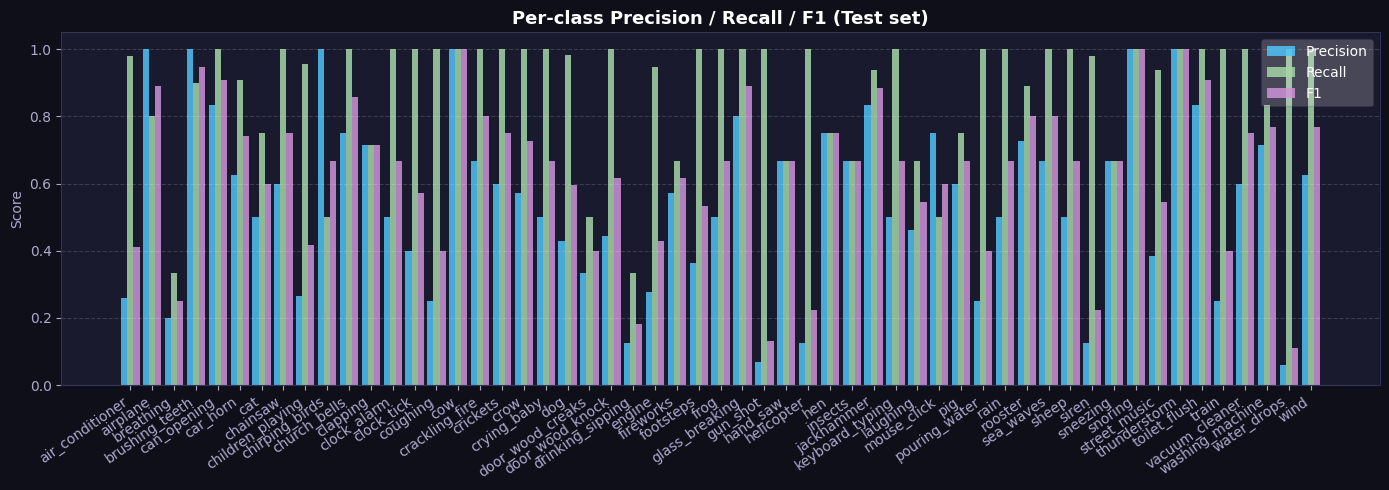

✅ Per-class metrics plot saved → C:\Users\shara\Desktop\ALM\outputs\figures\multilabel_per_class_metrics.png


In [23]:
prec_per_class = precision_score(all_labels, all_preds, average=None, zero_division=0)
rec_per_class  = recall_score(all_labels,   all_preds, average=None, zero_division=0)
f1_per_class   = f1_score(all_labels,       all_preds, average=None, zero_division=0)

x = np.arange(NUM_CLASSES)
width = 0.28

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')
ax.bar(x - width, prec_per_class, width, label='Precision', color='#4fc3f7', alpha=0.85)
ax.bar(x,          rec_per_class,  width, label='Recall',    color='#a5d6a7', alpha=0.85)
ax.bar(x + width,  f1_per_class,   width, label='F1',        color='#ce93d8', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=35, ha='right', color='#aaaacc')
ax.set_ylabel('Score', color='#aaaacc')
ax.set_title('Per-class Precision / Recall / F1 (Test set)',
             color='white', fontsize=13, fontweight='bold')
ax.tick_params(colors='#aaaacc')
for spine in ax.spines.values():
    spine.set_edgecolor('#333355')
ax.grid(axis='y', alpha=0.15, linestyle='--', color='white')
ax.legend(framealpha=0.2, labelcolor='white', edgecolor='#444466')

METRICS_PATH = PROJECT_ROOT / 'outputs' / 'figures' / "multilabel_per_class_metrics.png"
plt.tight_layout()
plt.savefig(METRICS_PATH, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Per-class metrics plot saved → {METRICS_PATH}")

## 1️⃣5️⃣ How to Load & Use the Saved Model

In [24]:
def load_multilabel_encoder(ckpt_path: str, device: str = 'cuda'):
    """
    Load a saved MultiLabelAudioEncoder checkpoint.

    Returns:
        enc          – model in eval mode on `device`
        label_classes – list of class names (index = class id)
        threshold    – decision threshold used during training
    """
    ckpt = torch.load(ckpt_path, map_location=device)
    cfg  = ckpt['config']

    enc = MultiLabelAudioEncoder(
        embed_dim   = cfg['embed_dim'],
        num_heads   = cfg.get('num_heads', 8),
        num_layers  = cfg.get('num_layers', 4),
        ff_dim      = cfg.get('ff_dim', 1024),
        num_classes = cfg['num_classes'],
    ).to(device)

    enc.load_state_dict(ckpt['model_state'])
    enc.eval()

    label_classes = ckpt.get('label_classes', [])
    threshold     = cfg.get('threshold', 0.5)

    print(f"✅ Loaded multi-label encoder")
    print(f"   Classes   : {label_classes}")
    print(f"   Threshold : {threshold}")

    return enc, label_classes, threshold


# ── Demo ─────────────────────────────────────────────────────────────────────
encoder, classes, thresh = load_multilabel_encoder(
    str(BEST_MODEL_PATH), device=str(CFG.DEVICE)
)

dummy_mel = torch.randn(1, 1, CFG.N_MELS, 157).to(CFG.DEVICE)

with torch.no_grad():
    logits = encoder(dummy_mel)        # (1, num_classes) raw logits
    probs  = torch.sigmoid(logits)     # (1, num_classes) probabilities
    emb    = encoder.encode(dummy_mel) # (1, embed_dim)   L2-norm embedding

print(f"\nLogit shape    : {logits.shape}")
print(f"Probs shape    : {probs.shape}")
print(f"Embedding shape: {emb.shape}")
print(f"Sample probs   : {probs[0].cpu().tolist()}")

✅ Loaded multi-label encoder
   Classes   : ['air_conditioner', 'airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn', 'cat', 'chainsaw', 'children_playing', 'chirping_birds', 'church_bells', 'clapping', 'clock_alarm', 'clock_tick', 'coughing', 'cow', 'crackling_fire', 'crickets', 'crow', 'crying_baby', 'dog', 'door_wood_creaks', 'door_wood_knock', 'drinking_sipping', 'engine', 'fireworks', 'footsteps', 'frog', 'glass_breaking', 'gun_shot', 'hand_saw', 'helicopter', 'hen', 'insects', 'jackhammer', 'keyboard_typing', 'laughing', 'mouse_click', 'pig', 'pouring_water', 'rain', 'rooster', 'sea_waves', 'sheep', 'siren', 'sneezing', 'snoring', 'street_music', 'thunderstorm', 'toilet_flush', 'train', 'vacuum_cleaner', 'washing_machine', 'water_drops', 'wind']
   Threshold : 0.2

Logit shape    : torch.Size([1, 55])
Probs shape    : torch.Size([1, 55])
Embedding shape: torch.Size([1, 256])
Sample probs   : [0.001063925214111805, 0.0004967809654772282, 0.0014475210336968303, 0.00

## 📦 Summary

| Artifact | Path |
|----------|------|
| Best model (lowest BCE loss) | `models/alm_multilabel_best.pth` |
| Final model (last epoch) | `models/alm_multilabel_final.pth` |
| Training curves plot | `outputs/figures/multilabel_training_curves.png` |
| Per-class metrics plot | `outputs/figures/multilabel_per_class_metrics.png` |

### Key Changes from Original

| Original (single-label) | New (multi-label) |
|-------------------------|-------------------|
| `CrossEntropyLoss` | `BCEWithLogitsLoss` (+ `pos_weight`) |
| softmax / argmax | sigmoid > threshold OR top-K fallback |
| int label targets | float multi-hot vectors |
| accuracy metric | F1 micro + macro, precision, recall |
| no augmentation mixing | audio mixing + pitch/stretch/noise aug |
| no rare-class handling | oversampling + targeted augmentation |

### References
- [BCEWithLogitsLoss — PyTorch docs](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html)
- [SpecAugment — Park et al., 2019](https://arxiv.org/abs/1904.08779)
- [Audio Spectrogram Transformer — Gong et al., 2021](https://arxiv.org/abs/2104.01778)
- [MixUp for audio — Zhang et al., 2018](https://arxiv.org/abs/1710.09412)

In [24]:
import pandas as pd
df = pd.read_csv(CFG.METADATA_PATH)
print(df['label'].value_counts())

label
dog_bark            1000
engine_idling       1000
children_playing    1000
street_music        1000
jackhammer          1000
drilling            1000
air_conditioner     1000
siren                969
car_horn             469
gun_shot             374
chainsaw              40
airplane              40
pouring_water         40
mouse_click           40
sheep                 40
water_drops           40
church_bells          40
dog                   40
vacuum_cleaner        40
thunderstorm          40
door_wood_knock       40
can_opening           40
crow                  40
clapping              40
fireworks             40
chirping_birds        40
crackling_fire        40
brushing_teeth        40
cow                   40
frog                  40
wind                  40
footsteps             40
keyboard_typing       40
clock_alarm           40
train                 40
helicopter            40
rain                  40
drinking_sipping      40
laughing              40
hen                